# Machine Learning Basics
Mohamed Ibrahim
BUS4-118S

## Part 1: House Price Prediction
Predict house prices using linear regression.

In [1]:
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# Data source: Ames Housing Dataset from OpenML
# OpenML ID: 42165
# https://www.openml.org/d/42165
# Contains 1,460 house records

housing = fetch_openml(name="house_prices", as_frame=True)

In [3]:
# Select the columns needed for this assignment
df = housing.frame[
    ["GrLivArea", "Neighborhood", "SalePrice"]
].copy()

In [4]:
# Rename columns to make them easier to understand
df = df.rename(columns={
    "GrLivArea": "square_footage",
    "Neighborhood": "location",
    "SalePrice": "price"
})

In [5]:
# Remove any missing values
df = df.dropna()


# Show how much data we are using
print("Number of houses:", len(df))
print(df.head())

Number of houses: 1460
   square_footage location   price
0            1710  CollgCr  208500
1            1262  Veenker  181500
2            1786  CollgCr  223500
3            1717  Crawfor  140000
4            2198  NoRidge  250000


In [6]:
# Features and target
X = df[["square_footage", "location"]]
y = df["price"]

In [7]:
# Convert the location column into numbers
preprocessor = ColumnTransformer(
    transformers=[
        (
            "location",
            OneHotEncoder(
                sparse_output=False,
                handle_unknown="ignore"
            ),
            ["location"]
        )
    ],
    remainder="passthrough"
)

In [8]:
# Create pipeline with preprocessing and Linear Regression
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [9]:
# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Train the model
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('location', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
# Predict the price of a new 2000 sq ft house
new_house = pd.DataFrame({
    "square_footage": [2000],
    "location": ["NAmes"]
})

In [12]:
predicted_price = model.predict(new_house)


print(
    f"\nPredicted price for a 2000 sq ft house in NAmes: "
    f"${predicted_price[0]:,.2f}"
)


Predicted price for a 2000 sq ft house in NAmes: $199,439.21


In [13]:
# Get feature names
feature_names = (
    model.named_steps["preprocessor"]
    .named_transformers_["location"]
    .get_feature_names_out(["location"])
).tolist() + ["square_footage"]

In [14]:
# Get model coefficients
coefficients = model.named_steps["regressor"].coef_

In [15]:
# Display model coefficients
print("\nModel Coefficients:")

for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")


Model Coefficients:
location_Blmngtn: 15916.57
location_Blueste: -36576.67
location_BrDale: -51780.44
location_BrkSide: -34350.03
location_ClearCr: 16301.31
location_CollgCr: 19492.68
location_Crawfor: 7062.28
location_Edwards: -40751.05
location_Gilbert: 2269.27
location_IDOTRR: -49248.61
location_MeadowV: -52983.05
location_Mitchel: -9646.37
location_NAmes: -20084.98
location_NPkVill: -17811.23
location_NWAmes: -9598.79
location_NoRidge: 70532.32
location_NridgHt: 97818.13
location_OldTown: -53131.10
location_SWISU: -62843.19
location_Sawyer: -22004.41
location_SawyerW: -4096.70
location_Somerst: 38318.51
location_StoneBr: 96251.05
location_Timber: 37058.39
location_Veenker: 63886.12
square_footage: 76.46


## Part 2: Customer Churn
Predict customer churn using logistic regression.

In [16]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [17]:
# Data source: IBM Telco Customer Churn Dataset
# Source: IBM GitHub
# Contains 7,043 customer records

df = pd.read_csv(
    "data/Telco-Customer-Churn.csv"
)

In [18]:
# Convert Churn from Yes/No to 1/0
df["churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [19]:
# Select features
X = df[
    [
        "tenure",
        "MonthlyCharges",
        "Contract",
        "InternetService"
    ]
]

y = df["churn"]

In [20]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            ["tenure", "MonthlyCharges"]
        ),
        (
            "cat",
            OneHotEncoder(
                sparse_output=False,
                handle_unknown="ignore"
            ),
            ["Contract", "InternetService"]
        )
    ]
)

In [21]:
# Create pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

In [22]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
# Train model
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
# Create a new customer
new_customer = pd.DataFrame({
    "tenure": [12],
    "MonthlyCharges": [75],
    "Contract": ["Month-to-month"],
    "InternetService": ["Fiber optic"]
})

In [25]:
# Predict churn probability
churn_probability = model.predict_proba(new_customer)[0][1]

In [26]:
# Classify using 0.5 threshold
threshold = 0.5

churn_prediction = (
    1 if churn_probability > threshold else 0
)

In [27]:
print(
    f"Churn Probability: "
    f"{churn_probability:.2f}"
)

print(
    f"Churn Prediction "
    f"(1 = churn, 0 = no churn): "
    f"{churn_prediction}"
)

Churn Probability: 0.61
Churn Prediction (1 = churn, 0 = no churn): 1


In [28]:
# Display model coefficients
feature_names = (
    ["tenure", "MonthlyCharges"] +
    model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(
        ["Contract", "InternetService"]
    ).tolist()
)

In [29]:
coefficients = model.named_steps["classifier"].coef_[0]

In [30]:
print("\nModel Coefficients:")

for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")


Model Coefficients:
tenure: -0.76
MonthlyCharges: 0.13
Contract_Month-to-month: 0.47
Contract_One year: -0.37
Contract_Two year: -1.28
InternetService_DSL: -0.44
InternetService_Fiber optic: 0.58
InternetService_No: -1.32


## Part 3: Customer Segmentation
Group customers using K-Means clustering.

In [31]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [32]:
# Data source: IBM Telco Customer Churn Dataset
# Source: IBM GitHub
# Contains 7,043 customer records

df = pd.read_csv(
    "data/Telco-Customer-Churn.csv"
)

print("Number of customers:", len(df))
print(df.head())

Number of customers: 7043
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

In [33]:
# Convert TotalCharges to numbers
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [34]:
# Remove missing values
df = df.dropna(
    subset=["tenure", "MonthlyCharges", "TotalCharges"]
)

In [35]:
# Select features for clustering
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X = df[features]

In [36]:
# Scale the data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [37]:
# Elbow Method
inertia = []

K = range(1, 6)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

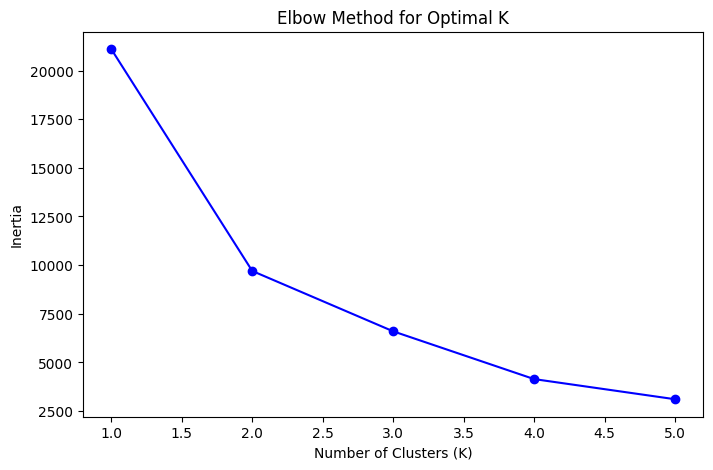

In [38]:
# Create elbow graph
plt.figure(figsize=(8, 5))

plt.plot(K, inertia, "bo-")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.savefig(
    "elbow_plot.png"
)

plt.show()

In [39]:
# Use 2 clusters
optimal_k = 2

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42
)

In [40]:
# Assign each customer to a cluster
df["cluster"] = kmeans.fit_predict(X_scaled)

In [41]:
# Show average characteristics of each cluster
cluster_summary = (
    df.groupby("cluster")[features]
    .mean()
    .round(2)
)

print("Cluster Characteristics:")

print(cluster_summary)

Cluster Characteristics:
         tenure  MonthlyCharges  TotalCharges
cluster                                      
0         56.87           89.76       5084.99
1         20.07           52.19        868.07


In [42]:
# Give a strategy for each cluster
for cluster in range(optimal_k):

    print(f"\nCluster {cluster} Strategy:")

    if cluster_summary.loc[cluster, "MonthlyCharges"] > 70:

        print(
            "High-paying customers: "
            "Offer loyalty rewards."
        )

    elif cluster_summary.loc[cluster, "tenure"] > 40:

        print(
            "Long-term customers: "
            "Offer renewal discounts."
        )

    else:

        print(
            "Newer customers: "
            "Send engagement offers."
        )


Cluster 0 Strategy:
High-paying customers: Offer loyalty rewards.

Cluster 1 Strategy:
Newer customers: Send engagement offers.


In [43]:
# Save customer clusters
df.to_csv(
    "customer_segments.csv",
    index=False
)

print("\nCustomer segments saved to customer_segments.csv")
print("Elbow plot saved to elbow_plot.png")


Customer segments saved to customer_segments.csv
Elbow plot saved to elbow_plot.png


## Part 4: Housing Sales Forecasting
Predict housing sales for the next six months.

In [44]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [45]:
# Data source: FRED
# Series: New One Family Houses Sold in the United States (HSN1F)
# Source: U.S. Census Bureau and HUD

df = pd.read_csv(
    "data/housing_sales.csv"
)

print("Number of records:", len(df))
print(df.head())

Number of records: 763
  observation_date  HSN1F
0       1963-01-01    591
1       1963-02-01    464
2       1963-03-01    461
3       1963-04-01    605
4       1963-05-01    586


In [46]:
# Rename columns
df = df.rename(columns={
    "observation_date": "date",
    "HSN1F": "sales"
})

In [47]:
# Convert date column
df["date"] = pd.to_datetime(df["date"])

In [48]:
# Remove missing sales values
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df = df.dropna()

In [49]:
# Create month numbers for the model
df["month"] = range(1, len(df) + 1)

In [50]:
# Features and target
X = df[["month"]]
y = df["sales"]

In [51]:
# Train model
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
# Predict next 6 months
future_months = pd.DataFrame({
    "month": range(
        df["month"].max() + 1,
        df["month"].max() + 7
    )
})

predictions = model.predict(future_months)

In [53]:
# Create future dates
future_dates = pd.date_range(
    start=df["date"].max() + pd.DateOffset(months=1),
    periods=6,
    freq="MS"
)

# Print forecast
print("Next 6 Months Forecast:")

for date, prediction in zip(future_dates, predictions):
    print(f"{date.strftime('%B %Y')}: {prediction:.2f}")

Next 6 Months Forecast:
August 2026: 712.49
September 2026: 712.64
October 2026: 712.79
November 2026: 712.93
December 2026: 713.08
January 2027: 713.23


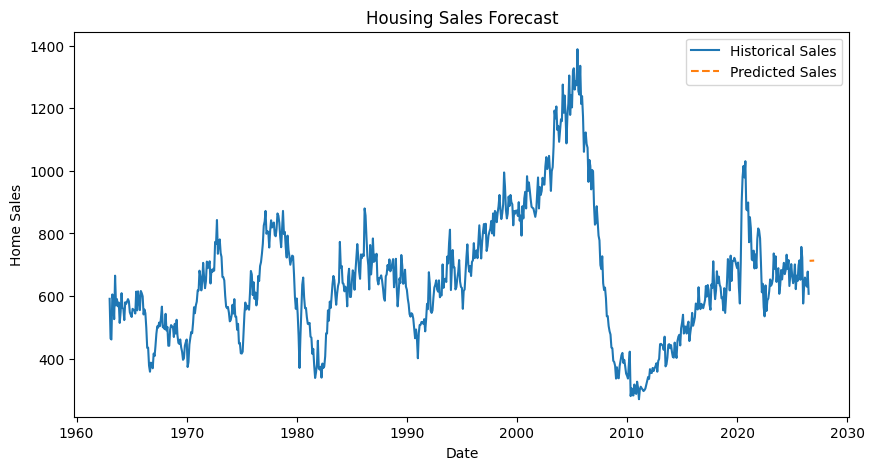

In [54]:
# Plot results
plt.figure(figsize=(10, 5))

plt.plot(
    df["date"],
    df["sales"],
    label="Historical Sales"
)

plt.plot(
    future_dates,
    predictions,
    label="Predicted Sales",
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Home Sales")
plt.title("Housing Sales Forecast")
plt.legend()

plt.savefig("housing_sales_forecast.png")
plt.show()

In [55]:
# Assignment notes
print("\nAssumption:")
print("The model assumes the overall sales trend continues.")

print("\nChallenge:")
print("Housing sales can change because of the economy and interest rates.")

print("\nPotential Improvement:")
print("The model could include more factors and seasonal patterns.")


Assumption:
The model assumes the overall sales trend continues.

Challenge:
Housing sales can change because of the economy and interest rates.

Potential Improvement:
The model could include more factors and seasonal patterns.
